# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [1]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
#%load_ext autoreload
#%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [2]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

C:\Users\wrx\assignment1\cs231n\data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.
### 表示（representation）比模型本身同样重要,即使模型是“简单线性分类器”，只要输入表示（features）更好，性能就能提高

In [3]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train Softmax classifier on features
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

In [4]:
from cs231n.classifiers.linear_classifier import Softmax

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5,1e-6]
regularization_strengths = [1e-1, 1, 10, 100,500]

results = {}
best_val = -1
best_softmax = None

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(
            X_train_feats, y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=3000,
            batch_size=200,
            verbose=False
        )

        y_train_pred = softmax.predict(X_train_feats)
        y_val_pred = softmax.predict(X_val_feats)

        train_accuracy = np.mean(y_train_pred == y_train)
        val_accuracy = np.mean(y_val_pred == y_val)

        results[(lr, reg)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved: %f' % best_val)

lr 1.000000e-06 reg 1.000000e-01 train accuracy: 0.090878 val accuracy: 0.075000
lr 1.000000e-06 reg 1.000000e+00 train accuracy: 0.076041 val accuracy: 0.088000
lr 1.000000e-06 reg 1.000000e+01 train accuracy: 0.086918 val accuracy: 0.079000
lr 1.000000e-06 reg 1.000000e+02 train accuracy: 0.110122 val accuracy: 0.093000
lr 1.000000e-06 reg 5.000000e+02 train accuracy: 0.100592 val accuracy: 0.104000
lr 5.000000e-05 reg 1.000000e-01 train accuracy: 0.099776 val accuracy: 0.099000
lr 5.000000e-05 reg 1.000000e+00 train accuracy: 0.110388 val accuracy: 0.108000
lr 5.000000e-05 reg 1.000000e+01 train accuracy: 0.093429 val accuracy: 0.100000
lr 5.000000e-05 reg 1.000000e+02 train accuracy: 0.089041 val accuracy: 0.087000
lr 5.000000e-05 reg 5.000000e+02 train accuracy: 0.109041 val accuracy: 0.124000
lr 1.000000e-04 reg 1.000000e-01 train accuracy: 0.092980 val accuracy: 0.085000
lr 1.000000e-04 reg 1.000000e+00 train accuracy: 0.103612 val accuracy: 0.119000
lr 1.000000e-04 reg 1.000000

In [5]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.115


In [6]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


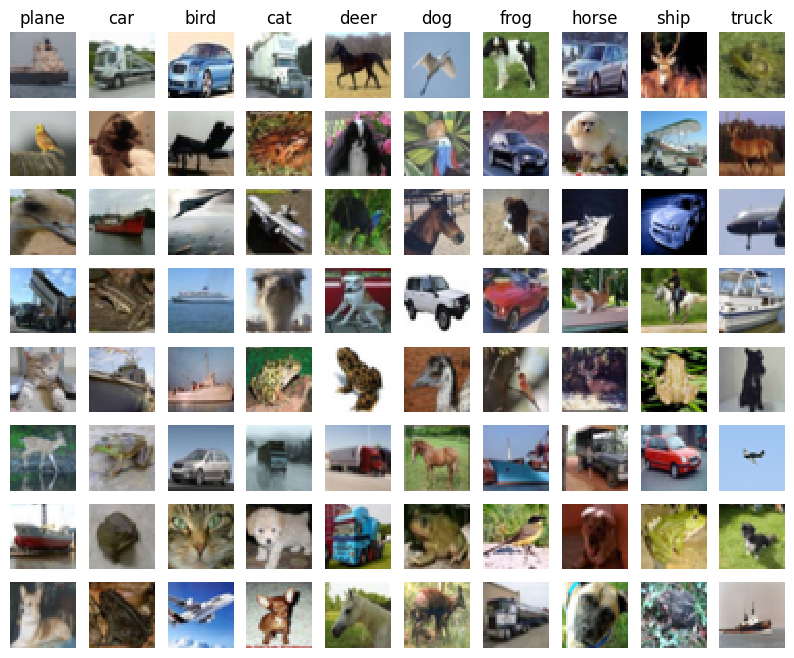

In [7]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer:}$





## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.
### 在图像特征上训练神经网络

In [8]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 170)
(49000, 169)


In [9]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}

net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################


results = {}
best_val = -1
best_net = None


learning_rates = [1e-3, 5e-4]
regularization_strengths = [1e-4, 1e-3, 5e-3]
hidden_dims = [300, 500]

for hd in hidden_dims:
    for lr in learning_rates:
        for reg in regularization_strengths:
            net = TwoLayerNet(
                input_dim=input_dim,
                hidden_dim=hd,
                num_classes=num_classes,
                weight_scale=1e-2,   # 起点可用，后面可微调
                reg=reg
            )

            solver = Solver(
                net,
                data,
                update_rule='adam',   # 比SGD更稳，收敛快
                optim_config={'learning_rate': lr},
                lr_decay=0.95,
                num_epochs=15,        # 先15轮快速筛；后面可加到20~30
                batch_size=200,
                print_every=100,
                verbose=False
            )

            solver.train()

            train_acc = solver.train_acc_history[-1]
            val_acc = solver.val_acc_history[-1]
            results[(hd, lr, reg)] = (train_acc, val_acc)

            print(f"hd={hd}, lr={lr:.1e}, reg={reg:.1e} | "
                  f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

            if val_acc > best_val:
                best_val = val_acc
                best_net = net

print("best validation accuracy achieved:", best_val)



hd=300, lr=1.0e-03, reg=1.0e-04 | train_acc=0.7550, val_acc=0.5840
hd=300, lr=1.0e-03, reg=1.0e-03 | train_acc=0.7620, val_acc=0.6000
hd=300, lr=1.0e-03, reg=5.0e-03 | train_acc=0.6600, val_acc=0.6080
hd=300, lr=5.0e-04, reg=1.0e-04 | train_acc=0.6860, val_acc=0.6040
hd=300, lr=5.0e-04, reg=1.0e-03 | train_acc=0.6870, val_acc=0.6180
hd=300, lr=5.0e-04, reg=5.0e-03 | train_acc=0.6220, val_acc=0.5950
hd=500, lr=1.0e-03, reg=1.0e-04 | train_acc=0.8250, val_acc=0.6130
hd=500, lr=1.0e-03, reg=1.0e-03 | train_acc=0.7870, val_acc=0.6010
hd=500, lr=1.0e-03, reg=5.0e-03 | train_acc=0.6590, val_acc=0.6010
hd=500, lr=5.0e-04, reg=1.0e-04 | train_acc=0.7400, val_acc=0.6120
hd=500, lr=5.0e-04, reg=1.0e-03 | train_acc=0.7200, val_acc=0.6070
hd=500, lr=5.0e-04, reg=5.0e-03 | train_acc=0.6620, val_acc=0.6010
best validation accuracy achieved: 0.618


In [10]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.569


In [11]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
